## Лабораторная работа №1
### «Анализ и прогнозирование временных рядов на примере розничных продаж»

**Данные:** `retail_sales_mock_data.csv`.

**Что делаем:** EDA → декомпозиция (классическая/FFT/вейвлет) → ARIMA и SARIMAX → метрики и анализ остатков → вывод.

In [15]:
# 1) Загрузка данных и предобработка

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import signal

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

from sklearn.metrics import mean_squared_error, r2_score

import pywt

DATA_PATH = "retail_sales_mock_data.csv"

In [16]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

# Индекс как временная шкала; частота начала месяца (MS)
df = df.set_index("Date")
df = df.asfreq("MS")

display(df.head(3))
print("shape:", df.shape)
print("date range:", df.index.min().date(), "→", df.index.max().date())
print("missing values:\n", df.isna().sum())

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0


shape: (48, 3)
date range: 2020-01-01 → 2023-12-01
missing values:
 SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64


**Вывод:** ряд месячный (период сезонности удобно брать **12**).

## 2.1 Разведочный анализ данных (EDA)

count       48.000000
mean     11768.541667
std       2257.544863
min       7783.000000
25%      10219.750000
50%      11851.000000
75%      13014.000000
max      17996.000000
Name: SalesAmount, dtype: float64

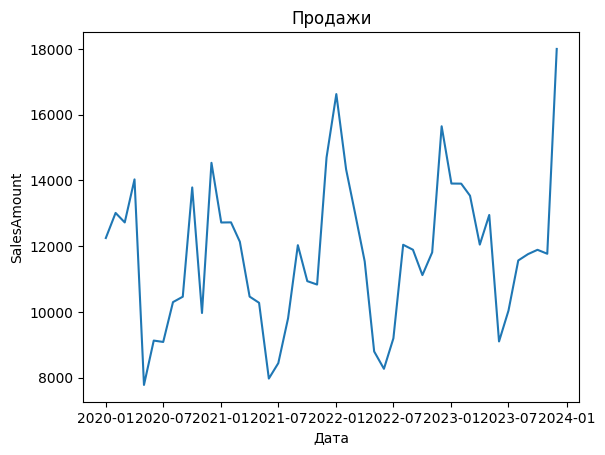

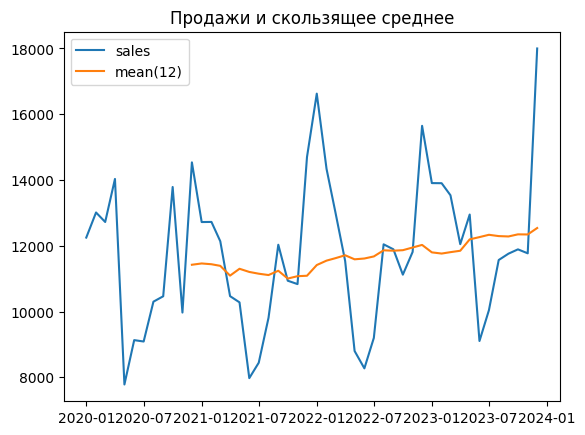

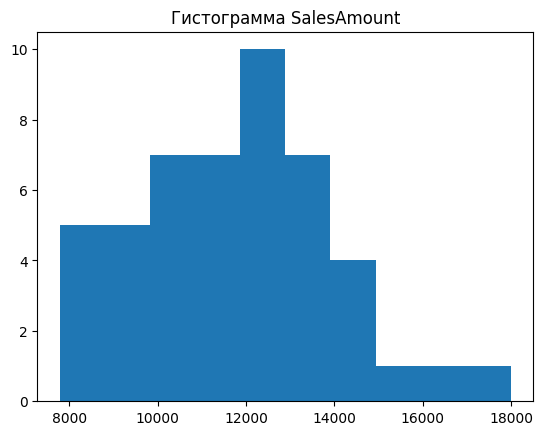

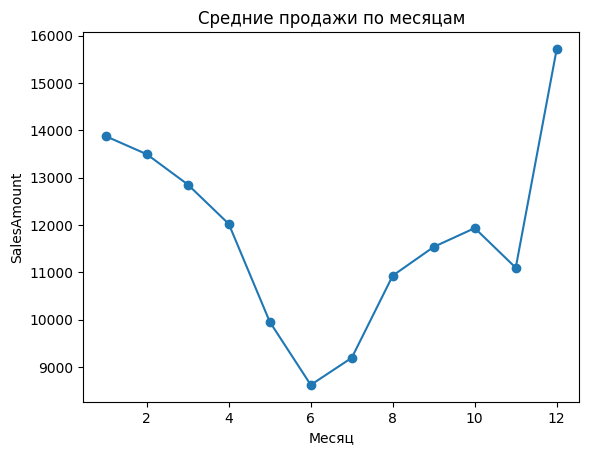

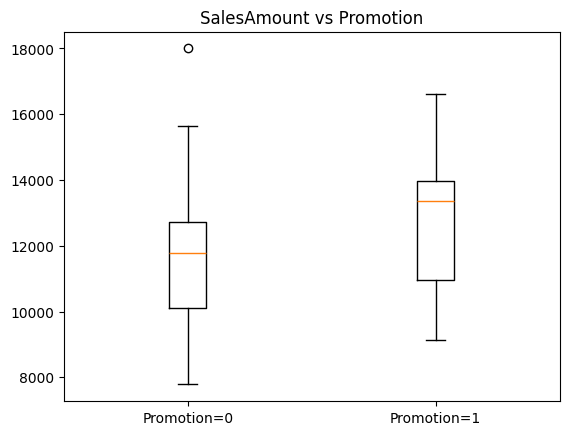

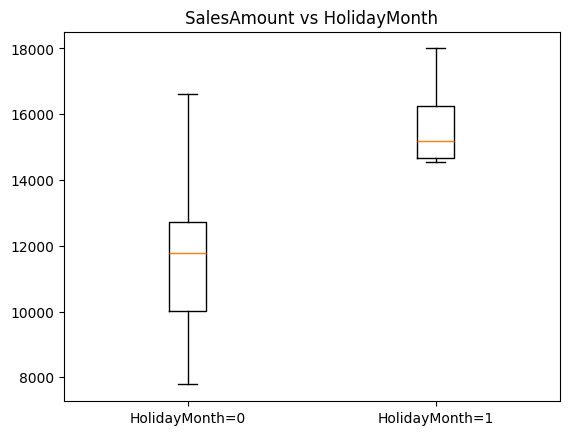

In [17]:
y = df["SalesAmount"].astype(float)
exog = df[["Promotion", "HolidayMonth"]].astype(float)

display(y.describe())

# Временной график
plt.figure()
plt.plot(y.index, y.values)
plt.title("Продажи")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")
plt.show()

# Скользящее среднее (12 месяцев)
plt.figure()
plt.plot(y.index, y.values, label="sales")
plt.plot(y.index, y.rolling(12).mean().values, label="mean(12)")
plt.legend()
plt.title("Продажи и скользящее среднее")
plt.show()

# Распределение
plt.figure()
plt.hist(y.values, bins=10)
plt.title("Гистограмма SalesAmount")
plt.show()

# Сезонность: средние продажи по месяцу
by_month_mean = y.groupby(y.index.month).mean().reindex(range(1, 13))
plt.figure()
plt.plot(range(1, 13), by_month_mean.values, marker="o")
plt.title("Средние продажи по месяцам")
plt.xlabel("Месяц")
plt.ylabel("SalesAmount")
plt.show()

# Экзогенные факторы: простые сравнения
plt.figure()
plt.boxplot([y[exog["Promotion"] == 0].values, y[exog["Promotion"] == 1].values], tick_labels=["Promotion=0", "Promotion=1"])
plt.title("SalesAmount vs Promotion")
plt.show()

plt.figure()
plt.boxplot([y[exog["HolidayMonth"] == 0].values, y[exog["HolidayMonth"] == 1].values], tick_labels=["HolidayMonth=0", "HolidayMonth=1"])
plt.title("SalesAmount vs HolidayMonth")
plt.show()

,name,adf_stat,p_value,nobs
0,SalesAmount,-4.514184,0.000185,42
1,diff1,-5.629594,0.000001,36
2,diff12,-3.626089,0.005281,32
3,diff1+diff12,-4.669731,0.000096,29


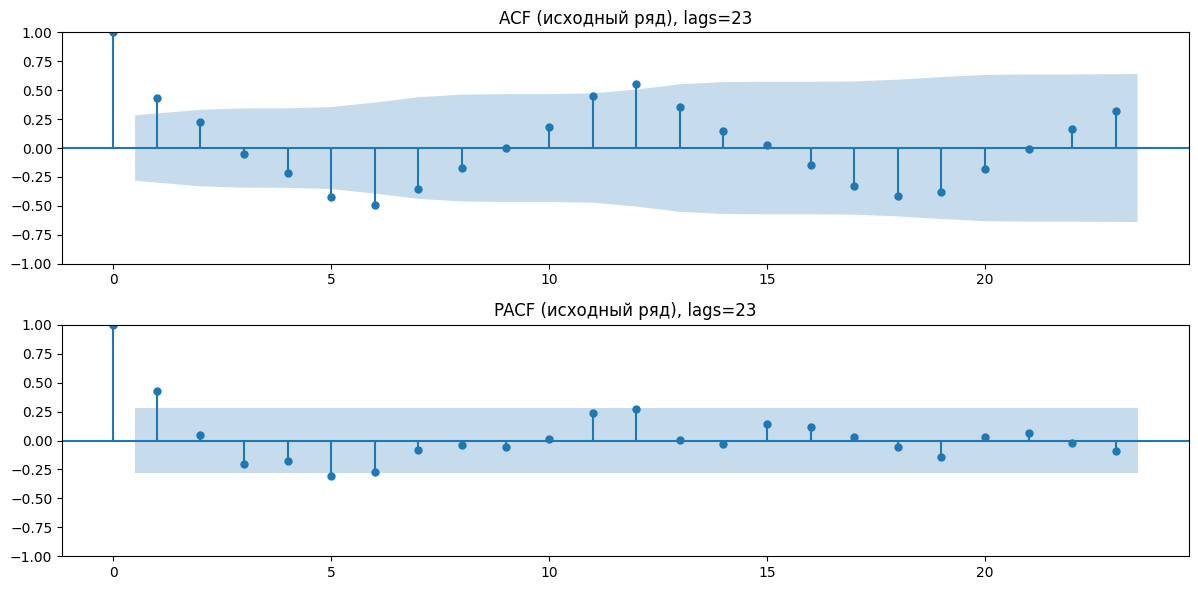

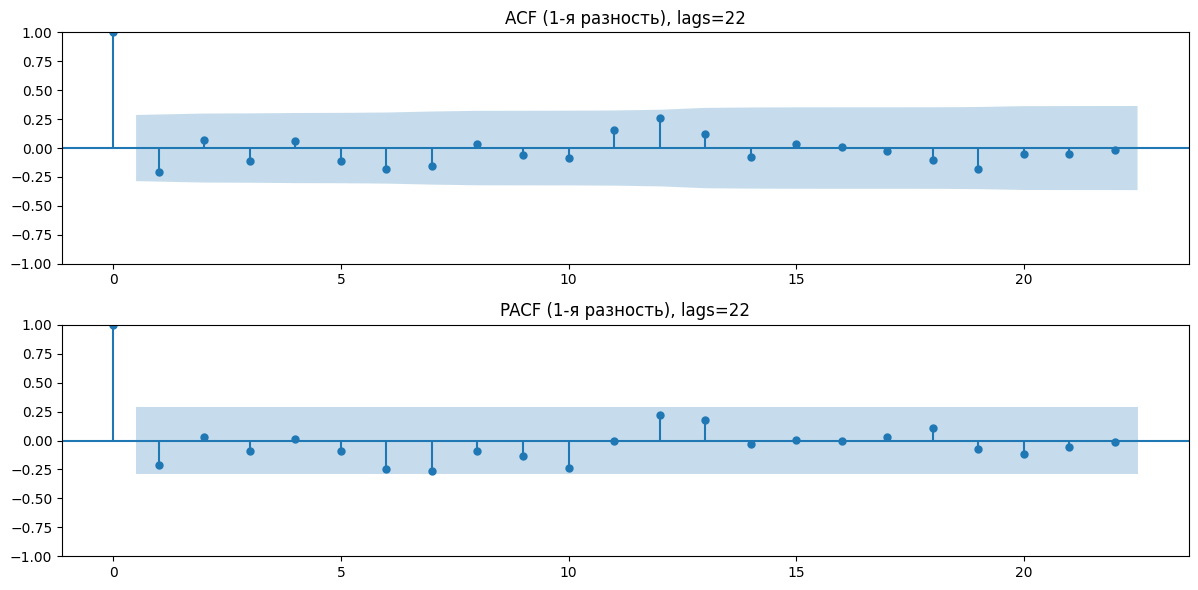

In [18]:
# Проверка стационарности (ADF) + ACF/PACF

def adf_test(series, name="series"):
    s = pd.Series(series).dropna().astype(float)
    res = adfuller(s, autolag="AIC")
    return {
        "name": name,
        "adf_stat": res[0],
        "p_value": res[1],
        "nobs": res[3],
    }


def safe_nlags(series, target=24):
    s = pd.Series(series).dropna()
    # Ограничение statsmodels: nlags < n/2
    return int(min(target, max(1, (len(s) // 2) - 1)))

adf_df = pd.DataFrame([
    adf_test(y, "SalesAmount"),
    adf_test(y.diff(1), "diff1"),
    adf_test(y.diff(12), "diff12"),
    adf_test(y.diff(1).diff(12), "diff1+diff12"),
])
display(adf_df)

# Исходный ряд
lags0 = safe_nlags(y, target=24)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(y.dropna(), ax=ax[0], lags=lags0)
ax[0].set_title(f"ACF (исходный ряд), lags={lags0}")
plot_pacf(y.dropna(), ax=ax[1], lags=lags0, method="ywm")
ax[1].set_title(f"PACF (исходный ряд), lags={lags0}")
plt.tight_layout()
plt.show()

# 1-я разность
yd1 = y.diff(1).dropna()
lags1 = safe_nlags(yd1, target=24)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(yd1, ax=ax[0], lags=lags1)
ax[0].set_title(f"ACF (1-я разность), lags={lags1}")
plot_pacf(yd1, ax=ax[1], lags=lags1, method="ywm")
ax[1].set_title(f"PACF (1-я разность), lags={lags1}")
plt.tight_layout()
plt.show()

**Вывод:** по сезонной агрегации видно годовую сезонность (≈**12**). Признаки `Promotion` и `HolidayMonth` разумно использовать как экзогенные факторы в `SARIMAX`.

## 2.1 Декомпозиция ряда (3 подхода)

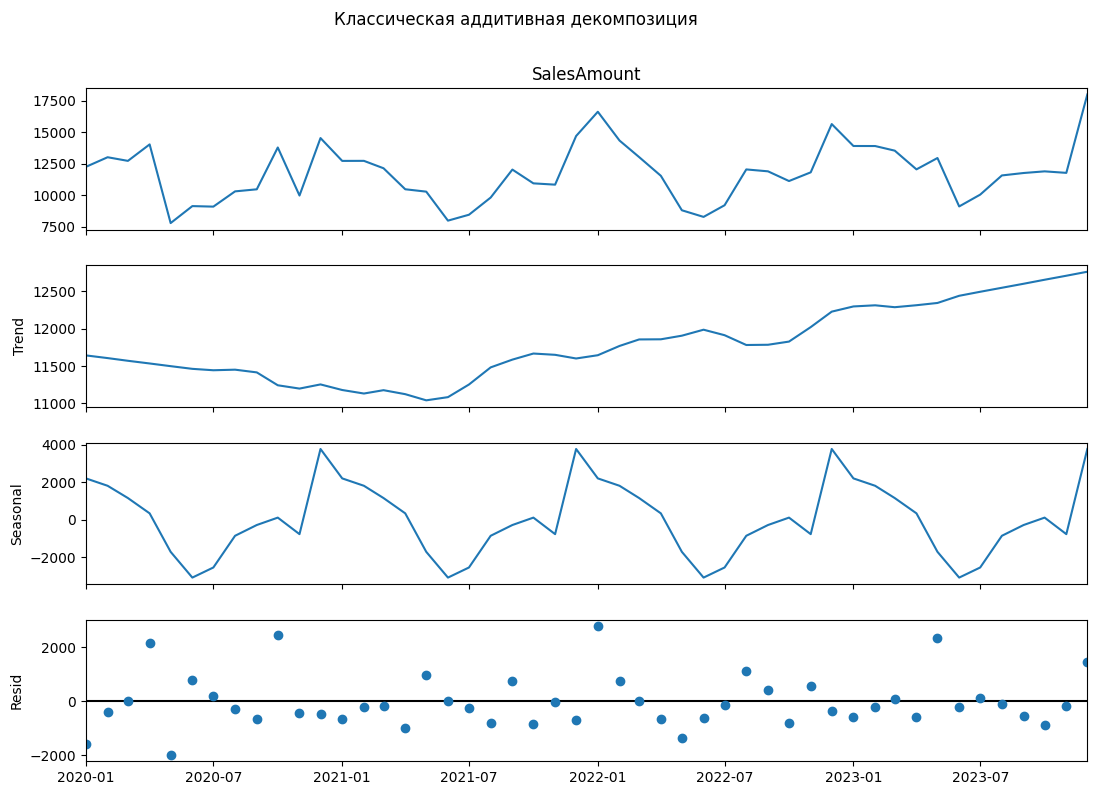

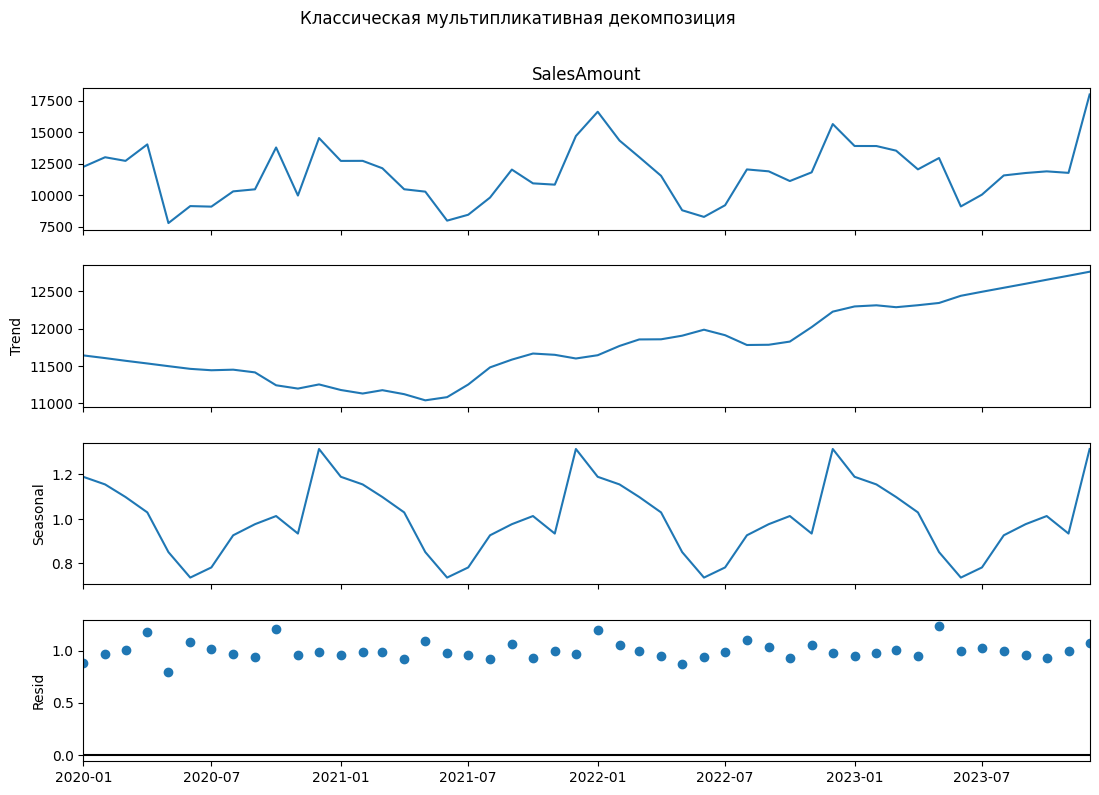

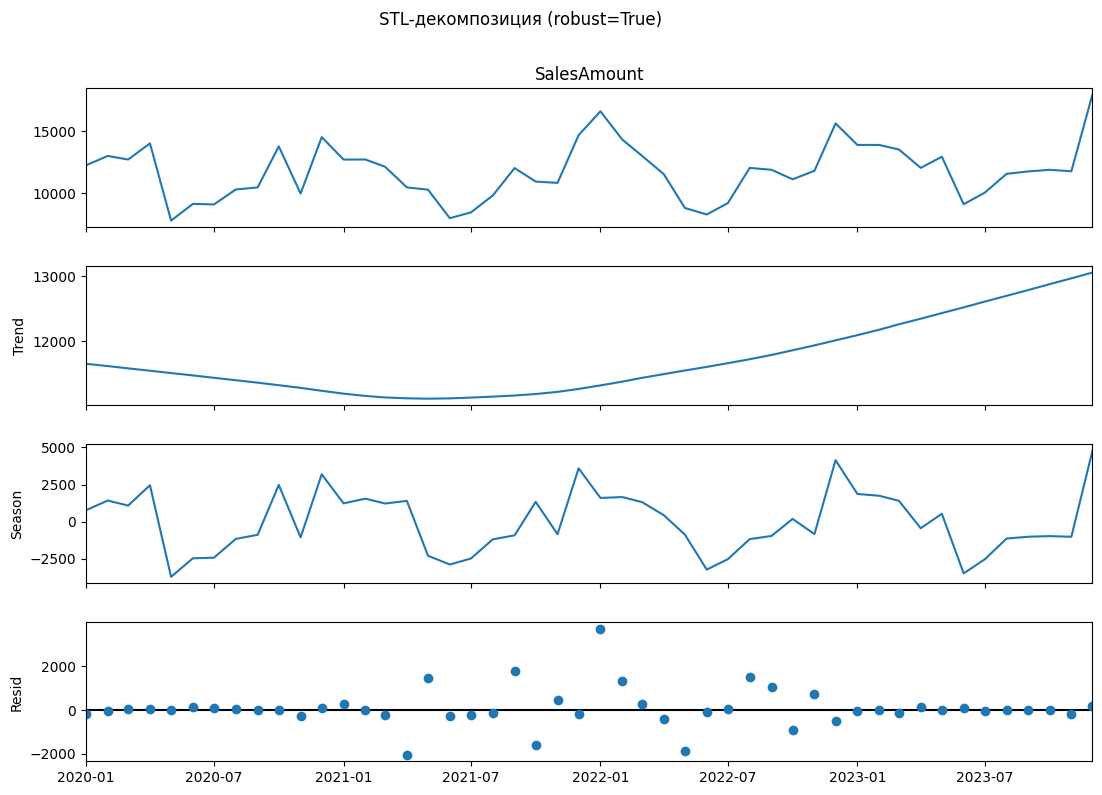

In [19]:
# (1) Классическая декомпозиция: аддитивная, мультипликативная, STL

period = 12

# Для мультипликативной декомпозиции нужны строго положительные значения
if (y <= 0).any():
    raise ValueError("Для мультипликативной декомпозиции SalesAmount должны быть > 0")

res_add = seasonal_decompose(y, model="additive", period=period, extrapolate_trend="freq")
res_mul = seasonal_decompose(y, model="multiplicative", period=period, extrapolate_trend="freq")
res_stl = STL(y, period=period, robust=True).fit()

fig = res_add.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Классическая аддитивная декомпозиция", y=1.02)
plt.show()

fig = res_mul.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Классическая мультипликативная декомпозиция", y=1.02)
plt.show()

fig = res_stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL-декомпозиция (robust=True)", y=1.02)
plt.show()

,period_months,amplitude
0,12.000000,58111.281744
1,4.000000,20169.892098
2,2.000000,16066.593139
3,6.000000,13752.887346
4,2.400000,12845.403788
5,2.086957,12415.917017
6,2.181818,12329.701205
7,3.692308,11271.122213
8,3.428571,10857.729778
9,3.000000,10848.769423


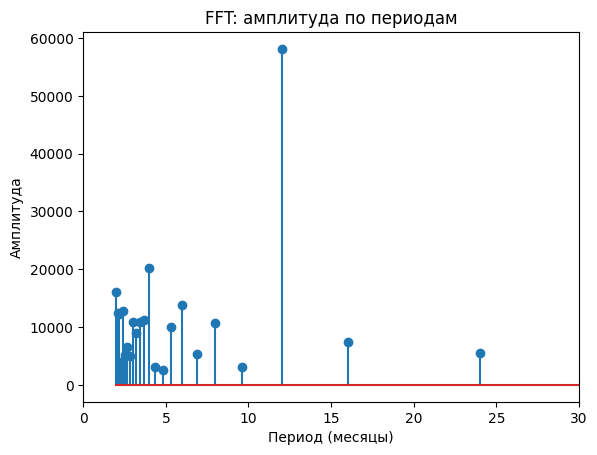

In [20]:
# (2) Спектральный анализ (FFT)

s_detr = signal.detrend(y.values.astype(float))

n = len(s_detr)
freqs = np.fft.rfftfreq(n, d=1.0)  # шаг = 1 месяц
fft_vals = np.fft.rfft(s_detr)
amp = np.abs(fft_vals)

mask = freqs > 0
freqs = freqs[mask]
amp = amp[mask]
periods = 1 / freqs

order = np.argsort(amp)[::-1]
top = pd.DataFrame({
    "period_months": periods[order][:10],
    "amplitude": amp[order][:10],
})
display(top)

plt.figure()
plt.stem(periods, amp)
plt.xlim(0, 30)
plt.title("FFT: амплитуда по периодам")
plt.xlabel("Период (месяцы)")
plt.ylabel("Амплитуда")
plt.show()

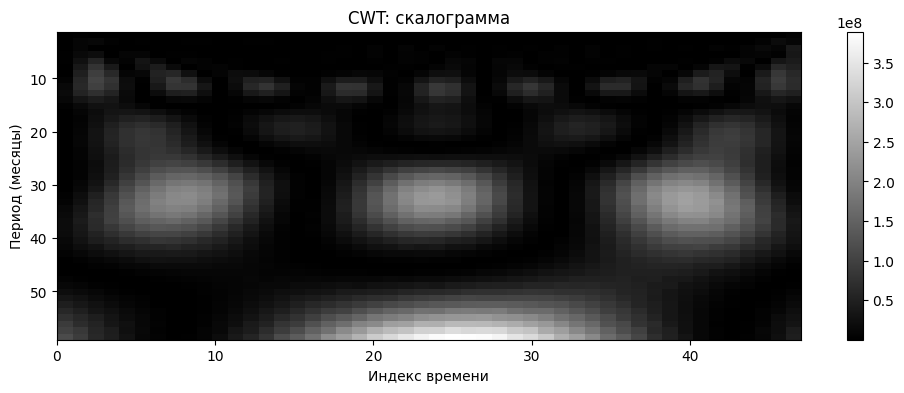

In [21]:
# (3) Вейвлет-анализ (CWT, Morlet)

s_vals = y.values.astype(float)
scales = np.arange(1, 49)
wavelet = "morl"

coeffs, _ = pywt.cwt(s_vals, scales=scales, wavelet=wavelet)
power = np.abs(coeffs) ** 2

pseudo_freq = pywt.scale2frequency(wavelet, scales)
pseudo_period = 1 / pseudo_freq

plt.figure(figsize=(12, 4))
extent = [0, len(y) - 1, pseudo_period.max(), pseudo_period.min()]
plt.imshow(power, extent=extent, aspect="auto", cmap="gray")
plt.title("CWT: скалограмма")
plt.xlabel("Индекс времени")
plt.ylabel("Период (месяцы)")
plt.colorbar()
plt.show()

**Вывод:**
- Классическая декомпозиция и STL дают интерпретируемые компоненты (тренд/сезонность/остаток).
- FFT подтверждает наличие доминирующего периода (в нашем случае ожидаемо около **12 месяцев**).
- Вейвлет (CWT) показывает, как сезонная компонента проявляется во времени (полезно при нестационарности).

## 2.2 Построение прогнозных моделей (ARIMA и SARIMAX)

In [22]:
# Разделение на train/test
# При 48 точках разумно оставить последние 12 месяцев на тест.

test_size = 12
train_y, test_y = y.iloc[:-test_size], y.iloc[-test_size:]
train_exog, test_exog = exog.iloc[:-test_size], exog.iloc[-test_size:]

print("train:", train_y.index.min().date(), "→", train_y.index.max().date(), "n=", len(train_y))
print("test :", test_y.index.min().date(), "→", test_y.index.max().date(), "n=", len(test_y))

# Горизонт прогноза: максимально возможный на test
h = len(test_y)
assert h == test_size

train: 2020-01-01 → 2022-12-01 n= 36
test : 2023-01-01 → 2023-12-01 n= 12


In [23]:
# Подбор параметров по AIC (без шума ConvergenceWarning)

from itertools import product

from statsmodels.tools.sm_exceptions import ConvergenceWarning


def fit_sarimax(
    endog,
    exog=None,
    order=(1, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend="n",
    maxiter=300,
):
    model = SARIMAX(
        endog,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    # На коротких рядах часть комбинаций не сходится — это нормально.
    # Подавляем ConvergenceWarning и отбрасываем несошедшиеся модели.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        res = model.fit(disp=False, method="lbfgs", maxiter=maxiter)

    converged = bool(getattr(res, "mle_retvals", {}).get("converged", True))
    if not converged:
        raise ValueError("Модель не сошлась")
    return res


def grid_search_aic(
    endog,
    exog=None,
    p_range=(0, 1, 2),
    d_range=(0, 1),
    q_range=(0, 1, 2),
    P_range=(0, 1),
    D_range=(0, 1),
    Q_range=(0, 1),
    s=12,
    seasonal=True,
    trend="n",
    max_evals=200,
):
    rows = []
    evals = 0

    for (p, d, q) in product(p_range, d_range, q_range):
        if seasonal:
            for (P, D, Q) in product(P_range, D_range, Q_range):
                seasonal_order = (P, D, Q, s)
                try:
                    res = fit_sarimax(
                        endog,
                        exog=exog,
                        order=(p, d, q),
                        seasonal_order=seasonal_order,
                        trend=trend,
                    )
                except Exception:
                    continue

                rows.append({
                    "order": (p, d, q),
                    "seasonal_order": seasonal_order,
                    "aic": float(res.aic),
                    "bic": float(res.bic),
                })

                evals += 1
                if evals >= max_evals:
                    break
            if evals >= max_evals:
                break
        else:
            try:
                res = fit_sarimax(
                    endog,
                    exog=exog,
                    order=(p, d, q),
                    seasonal_order=(0, 0, 0, 0),
                    trend=trend,
                )
            except Exception:
                continue

            rows.append({
                "order": (p, d, q),
                "seasonal_order": (0, 0, 0, 0),
                "aic": float(res.aic),
                "bic": float(res.bic),
            })

            evals += 1
            if evals >= max_evals:
                break

    out = pd.DataFrame(rows)
    out = out.sort_values(["aic", "bic"], ascending=True).reset_index(drop=True)
    return out

In [24]:
# 1) ARIMA (без сезонности и без экзогенных факторов) — базовая модель
# Поскольку данных мало, ограничимся небольшими диапазонами.

arima_candidates = grid_search_aic(
    train_y,
    exog=None,
    p_range=(0, 1, 2, 3),
    d_range=(0, 1),
    q_range=(0, 1, 2, 3),
    seasonal=False,
    trend="n",
    max_evals=300,
)

display(arima_candidates.head(10))

best_arima_order = tuple(arima_candidates.loc[0, "order"])
print("Best ARIMA order:", best_arima_order)

arima_res = fit_sarimax(train_y, exog=None, order=best_arima_order, seasonal_order=(0, 0, 0, 0), trend="n")
print(arima_res.summary())

,order,seasonal_order,aic,bic
0,"(3, 1, 3)","(0, 0, 0, 0)",561.265197,571.303107
1,"(0, 1, 3)","(0, 0, 0, 0)",561.907967,567.643916
2,"(1, 1, 3)","(0, 0, 0, 0)",563.857219,571.027155
3,"(2, 1, 3)","(0, 0, 0, 0)",564.668133,573.272056
4,"(2, 0, 3)","(0, 0, 0, 0)",586.894995,595.689411
5,"(3, 1, 1)","(0, 0, 0, 0)",587.488802,594.817482
6,"(3, 1, 2)","(0, 0, 0, 0)",588.565922,597.360338
7,"(3, 0, 3)","(0, 0, 0, 0)",588.645244,598.905395
8,"(1, 0, 3)","(0, 0, 0, 0)",589.295559,596.624239
9,"(0, 1, 2)","(0, 0, 0, 0)",590.827155,595.224363


Best ARIMA order: (3, 1, 3)
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -273.633
Date:                Wed, 11 Mar 2026   AIC                            561.265
Time:                        11:58:52   BIC                            571.303
Sample:                    01-01-2020   HQIC                           564.537
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0575      0.302     -3.500      0.000      -1.650      -0.465
ar.L2          0.2294      0.548      0.419      0.675      -0.844       1.303
ar.L3          0.4319   

In [25]:
# 2) SARIMAX (сезонность 12 + экзогенные факторы)

sarimax_candidates = grid_search_aic(
    train_y,
    exog=train_exog,
    p_range=(0, 1, 2),
    d_range=(0, 1),
    q_range=(0, 1, 2),
    P_range=(0, 1),
    D_range=(0, 1),
    Q_range=(0, 1),
    s=12,
    seasonal=True,
    trend="n",
    max_evals=300,
)

display(sarimax_candidates.head(10))

best_sarimax_order = tuple(sarimax_candidates.loc[0, "order"])
best_sarimax_seasonal = tuple(sarimax_candidates.loc[0, "seasonal_order"])
print("Best SARIMAX order:", best_sarimax_order)
print("Best SARIMAX seasonal_order:", best_sarimax_seasonal)

sarimax_res = fit_sarimax(train_y, exog=train_exog, order=best_sarimax_order, seasonal_order=best_sarimax_seasonal, trend="n")
print(sarimax_res.summary())

,order,seasonal_order,aic,bic
0,"(2, 1, 2)","(0, 1, 1, 12)",133.731265,134.366797
1,"(0, 1, 2)","(0, 1, 1, 12)",134.775303,135.251953
2,"(2, 1, 2)","(1, 1, 1, 12)",135.579404,136.294378
3,"(0, 1, 2)","(1, 1, 1, 12)",135.940753,136.496843
4,"(1, 1, 2)","(1, 1, 1, 12)",137.936501,138.572033
5,"(1, 1, 2)","(0, 1, 1, 12)",138.517729,139.073820
6,"(2, 1, 1)","(0, 1, 1, 12)",146.392994,147.773566
7,"(2, 1, 0)","(1, 1, 0, 12)",147.387811,148.571158
8,"(2, 1, 1)","(1, 1, 1, 12)",148.267930,149.845727
9,"(2, 1, 0)","(1, 1, 1, 12)",148.989136,150.369708


Best SARIMAX order: (2, 1, 2)
Best SARIMAX seasonal_order: (0, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                          SalesAmount   No. Observations:                   36
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                 -58.866
Date:                              Wed, 11 Mar 2026   AIC                            133.731
Time:                                      11:59:18   BIC                            134.367
Sample:                                  01-01-2020   HQIC                           129.445
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2583.29

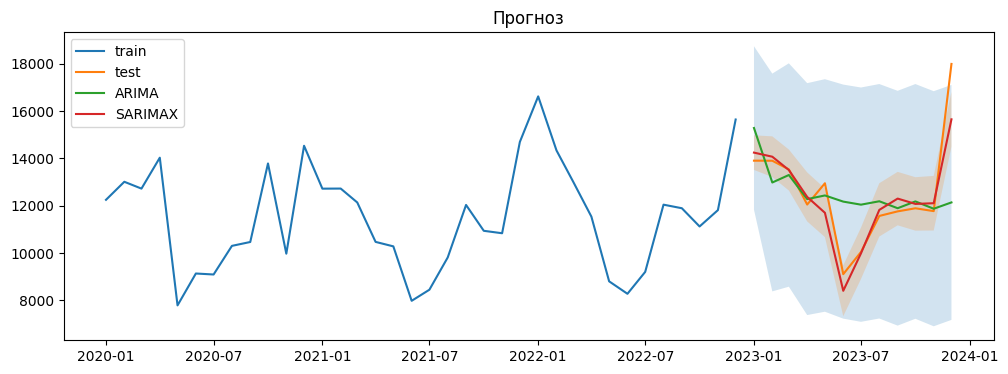

In [26]:
# Прогноз на тест (12 месяцев)

arima_fc = arima_res.get_forecast(steps=h)
arima_mean = arima_fc.predicted_mean
arima_ci = arima_fc.conf_int(alpha=0.05)

sarimax_fc = sarimax_res.get_forecast(steps=h, exog=test_exog)
sarimax_mean = sarimax_fc.predicted_mean
sarimax_ci = sarimax_fc.conf_int(alpha=0.05)

arima_mean.index = test_y.index
sarimax_mean.index = test_y.index

plt.figure(figsize=(12, 4))
plt.plot(train_y.index, train_y.values, label="train")
plt.plot(test_y.index, test_y.values, label="test")
plt.plot(test_y.index, arima_mean.values, label="ARIMA")
plt.plot(test_y.index, sarimax_mean.values, label="SARIMAX")

plt.fill_between(test_y.index, arima_ci.iloc[:, 0].values, arima_ci.iloc[:, 1].values, alpha=0.2)
plt.fill_between(test_y.index, sarimax_ci.iloc[:, 0].values, sarimax_ci.iloc[:, 1].values, alpha=0.2)

plt.title("Прогноз")
plt.legend()
plt.show()

**Вывод:** по подбору AIC получились модели:
- **ARIMA(3, 1, 3)** (базовая, без факторов)
- **SARIMAX(2, 1, 2)×(0, 1, 1, 12)** + `Promotion`, `HolidayMonth` (сезонная с факторами)

Далее сравнение делаем на тесте (12 месяцев) и по диагностике остатков.

## 2.3 Оценка качества моделей и анализ остатков

,model,MSE,R2,AIC,BIC
1,"SARIMAX(2, 1, 2)x(0, 1, 1, 12) + exog",6.923357e+05,0.850301,133.731265,134.366797
0,"ARIMA(3, 1, 3)",4.280700e+06,0.074414,561.265197,571.303107


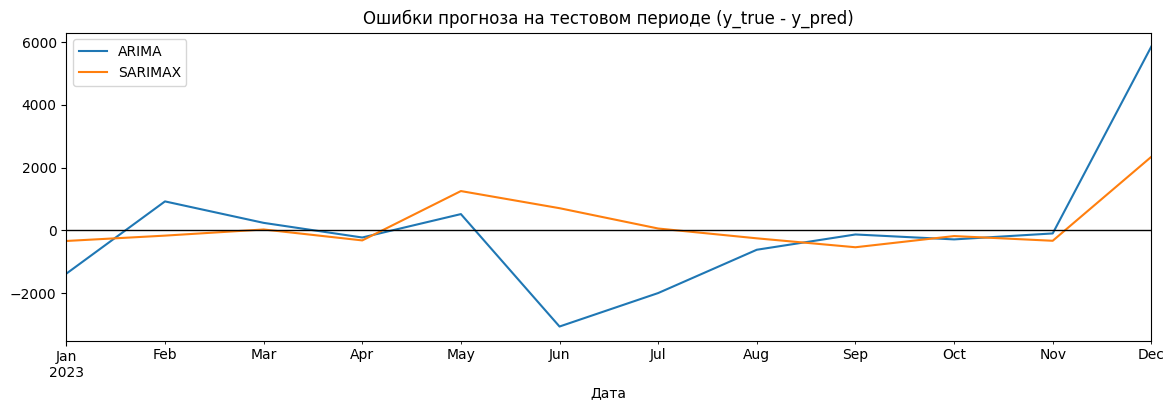

In [27]:
# Метрики на тесте

def eval_forecast(y_true, y_pred, name, aic, bic):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    return {
        "model": name,
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "AIC": float(aic),
        "BIC": float(bic),
    }

arima_metrics = eval_forecast(
    test_y,
    arima_mean.values,
    name=f"ARIMA{best_arima_order}",
    aic=arima_res.aic,
    bic=arima_res.bic,
)

sarimax_metrics = eval_forecast(
    test_y,
    sarimax_mean.values,
    name=f"SARIMAX{best_sarimax_order}x{best_sarimax_seasonal} + exog",
    aic=sarimax_res.aic,
    bic=sarimax_res.bic,
)

metrics_df = pd.DataFrame([arima_metrics, sarimax_metrics]).sort_values("MSE")
display(metrics_df)

# Ошибка по времени
err = pd.DataFrame({
    "y_true": test_y.values,
    "ARIMA": test_y.values - arima_mean.values,
    "SARIMAX": test_y.values - sarimax_mean.values,
}, index=test_y.index)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
err[["ARIMA", "SARIMAX"]].plot(ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Ошибки прогноза на тестовом периоде (y_true - y_pred)")
ax.set_xlabel("Дата")
plt.show()

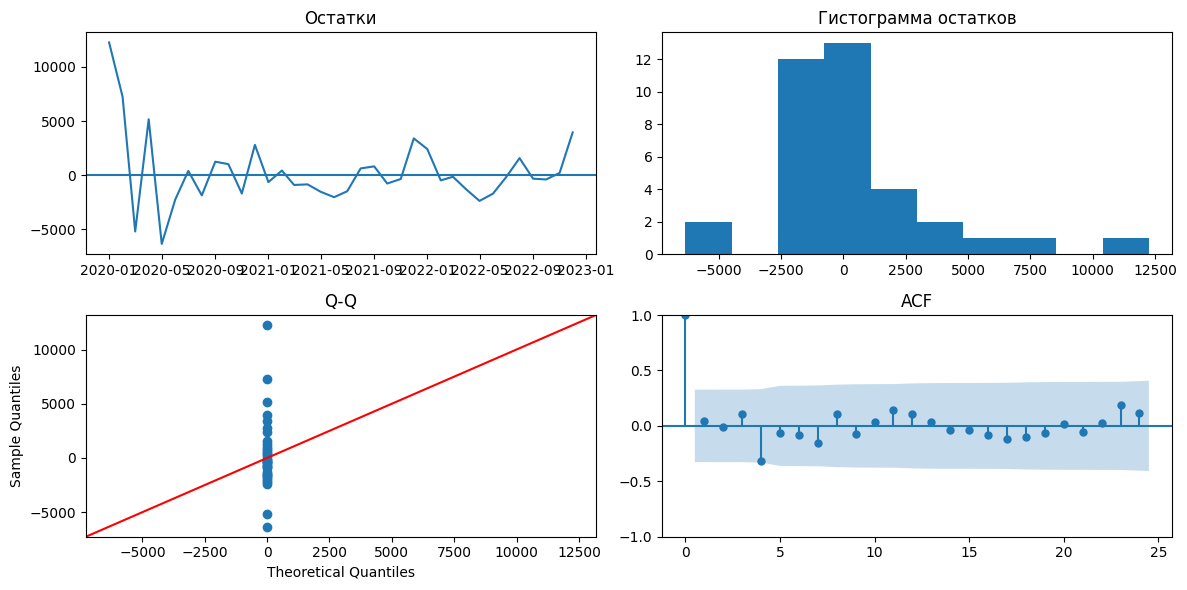

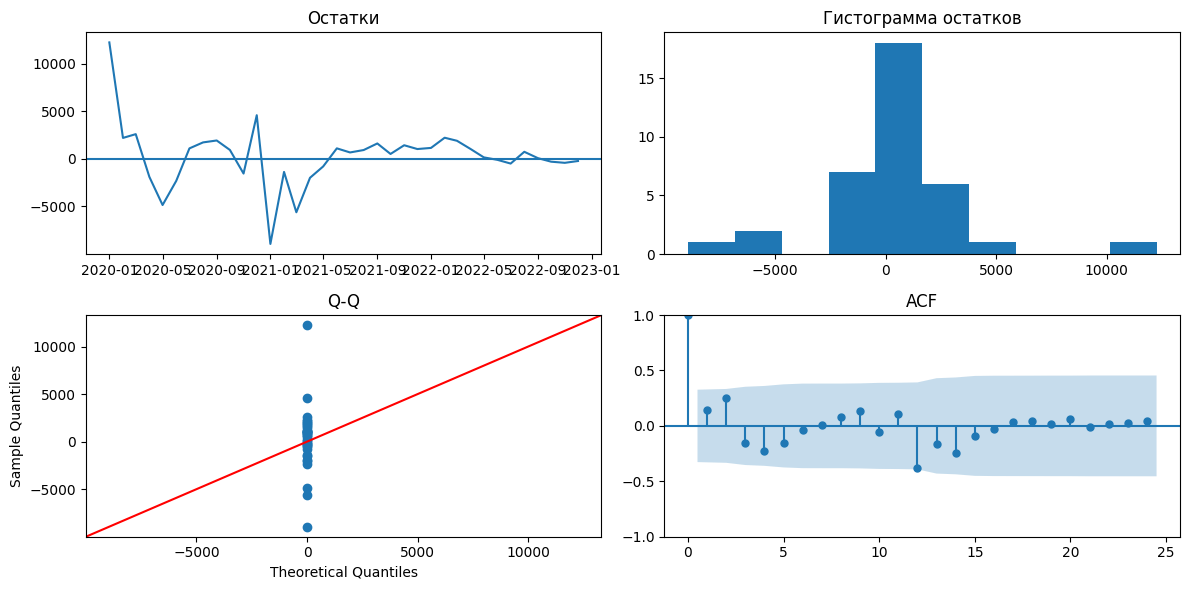

,model,JB_p,LjungBox_p(lag12),ARCH_p
0,ARIMA,3.092214e-08,0.686117,0.248625
1,SARIMAX,3.089879e-10,0.118659,0.872199


In [28]:
# Диагностика остатков

import statsmodels.api as sm


def residual_diagnostics(res, title):
    resid = pd.Series(res.resid).dropna().astype(float)

    _, jb_p, _, _ = jarque_bera(resid)
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    _, arch_p, _, _ = het_arch(resid)

    out = {
        "model": title,
        "JB_p": float(jb_p),
        "LjungBox_p(lag12)": float(lb["lb_pvalue"].iloc[0]),
        "ARCH_p": float(arch_p),
    }

    fig, ax = plt.subplots(2, 2, figsize=(12, 6))

    ax[0, 0].plot(resid.index, resid.values)
    ax[0, 0].axhline(0)
    ax[0, 0].set_title("Остатки")

    ax[0, 1].hist(resid.values, bins=10)
    ax[0, 1].set_title("Гистограмма остатков")

    sm.qqplot(resid, line="45", ax=ax[1, 0])
    ax[1, 0].set_title("Q-Q")

    plot_acf(resid, ax=ax[1, 1], lags=24)
    ax[1, 1].set_title("ACF")

    plt.tight_layout()
    plt.show()

    return out

arima_diag = residual_diagnostics(arima_res, "ARIMA")
sarimax_diag = residual_diagnostics(sarimax_res, "SARIMAX")

diag_df = pd.DataFrame([arima_diag, sarimax_diag])
display(diag_df)

**Вывод (по фактическим результатам):**
- По тесту (12 месяцев) **SARIMAX** лучше: MSE ≈ **6.92e5**, R² ≈ **0.85** (у ARIMA: MSE ≈ **4.28e6**, R² ≈ **0.07**).
- По AIC/BIC также лучше **SARIMAX**: AIC ≈ **133.73**, BIC ≈ **134.37** (у ARIMA: AIC ≈ **561.27**, BIC ≈ **571.30**).
- Остатки: автокорреляция по Ljung–Box не выявлена на лаге 12 (p≈0.69 у ARIMA, p≈0.12 у SARIMAX), ARCH-эффект незначим (p≈0.25 и p≈0.87).
- Нормальность остатков по Jarque–Bera отвергается у обеих моделей (p≈3e-8 и p≈3e-10), т.е. остатки не нормальные.

## 2.4 Документирование и интерпретация (итог)

### Итоговый вывод

По метрикам и критериям на тесте предпочтительна **SARIMAX(2,1,2)×(0,1,1,12) + exog**, т.к. она дала существенно меньшую ошибку и более высокий R².

Замечание: p-value Jarque–Bera у обеих моделей очень мал → остатки не нормальные (для прикладного прогноза это допустимо, но стоит учитывать при интерпретации доверительных интервалов).